In [1]:
import json
from pathlib import Path
from typing import Dict, List

from model_ranking import (
    plot_alpha_sweep_specific_norm,
    plot_performance_vs_transfer_metric_multi_target,
    match_model_names,
    to_target_transfer_correlations,
    correlation_table,
    load_transfer_metric_results,

)

INFO: P [MainThread] 2025-10-30 18:13:20,372 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
HtoR_Res_performance_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/HtoR_def_Hm_model_Res1/transfer_performance_F1_scores.json"
with open(HtoR_Res_performance_path, "r") as f:
    HtoR_Res_performance_scores = json.load(f)["performance_scores"]


In [3]:
VtoH_NA_performance_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_NA2/transfer_performance_F1_scores.json"
with open(VtoH_NA_performance_path, "r") as f:
    VtoH_NA_performance_scores = json.load(f)["performance_scores"]

In [4]:
VtoH_Res_performance_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_Res1/transfer_performance_F1_scores.json"
with open(VtoH_Res_performance_path, "r") as f:
    VtoH_Res_performance_scores = json.load(f)["performance_scores"]



# Per Perturbation CMB Consistency

Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/HtoR_def_Hm_model_Res1/EI_consis/CMB/transfer_gauss_a001-003_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a001-003
Number of targets: 1
  Target 1: Rmito


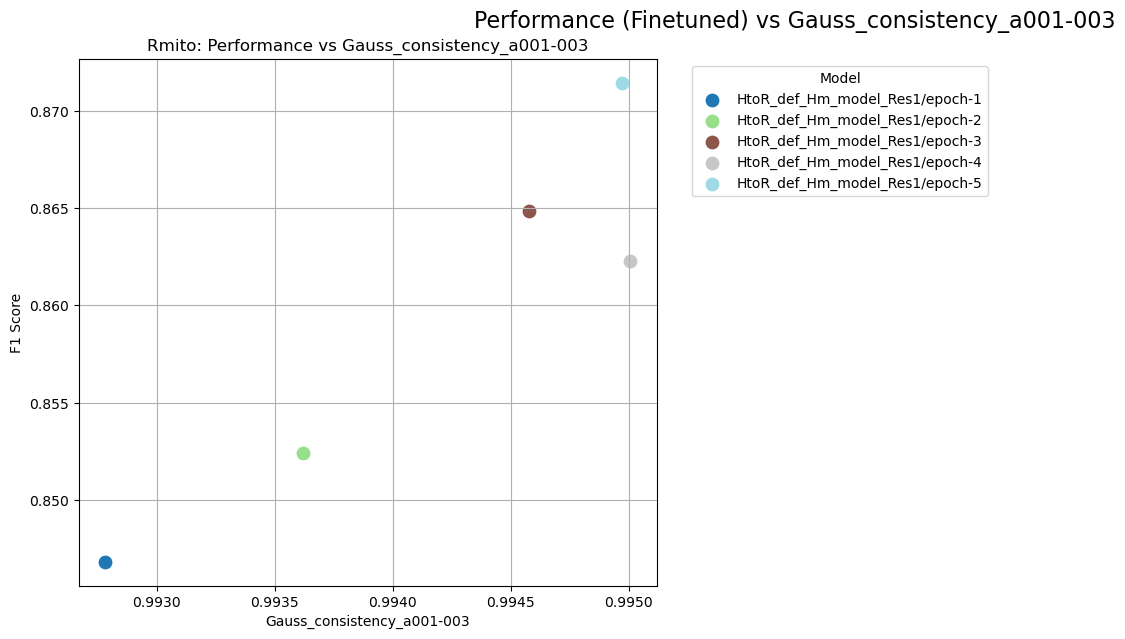

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.6     0.25    0.7        0.24  0.93     0.02
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/HtoR_def_Hm_model_Res1/EI_consis/CMB/transfer_gauss_a003-005_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a003-005
Number of targets: 1
  Target 1: Rmito


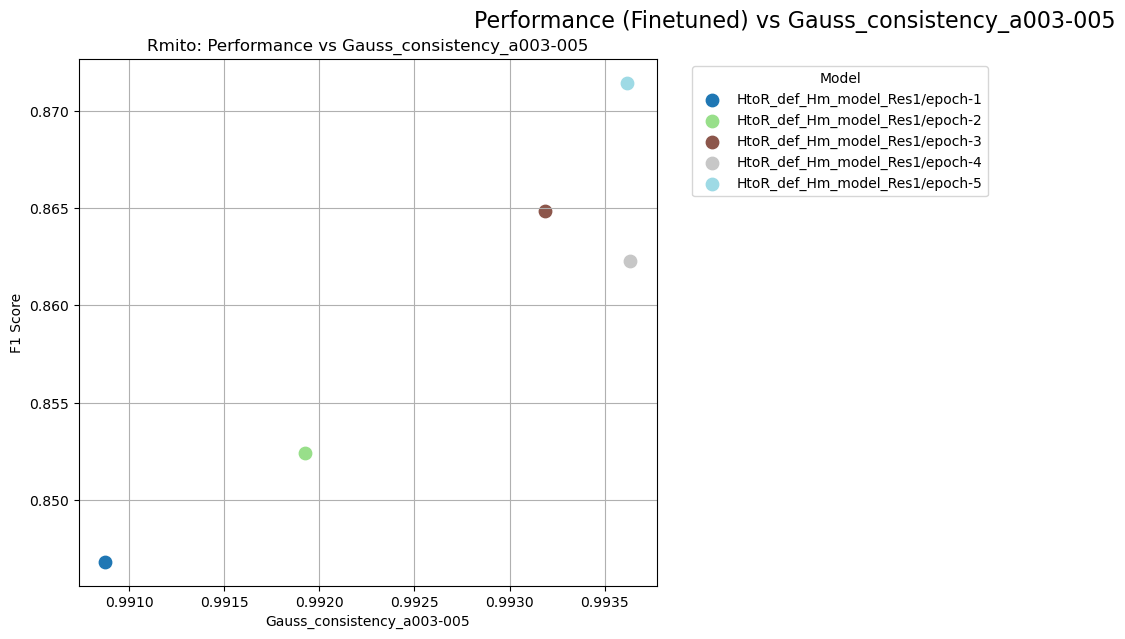

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.6     0.23    0.7        0.23  0.94     0.02
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/HtoR_def_Hm_model_Res1/EI_consis/CMB/transfer_gauss_a005-007_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a005-007
Number of targets: 1
  Target 1: Rmito


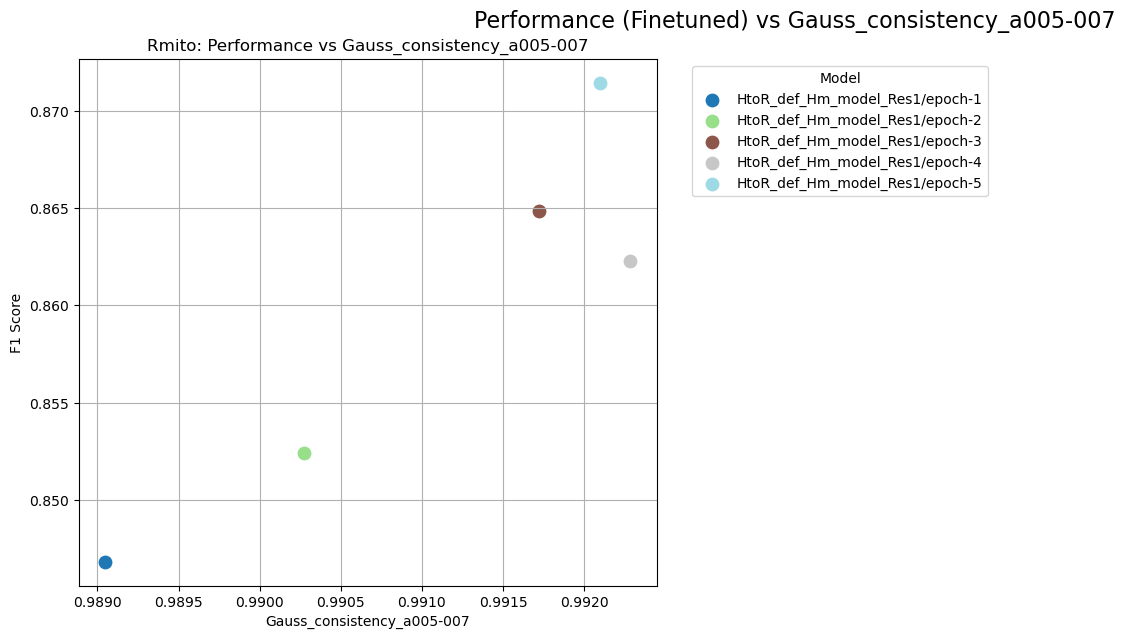

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.6     0.22    0.7        0.25  0.92     0.03
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/HtoR_def_Hm_model_Res1/EI_consis/CMB/transfer_gauss_a007-01_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a007-01
Number of targets: 1
  Target 1: Rmito


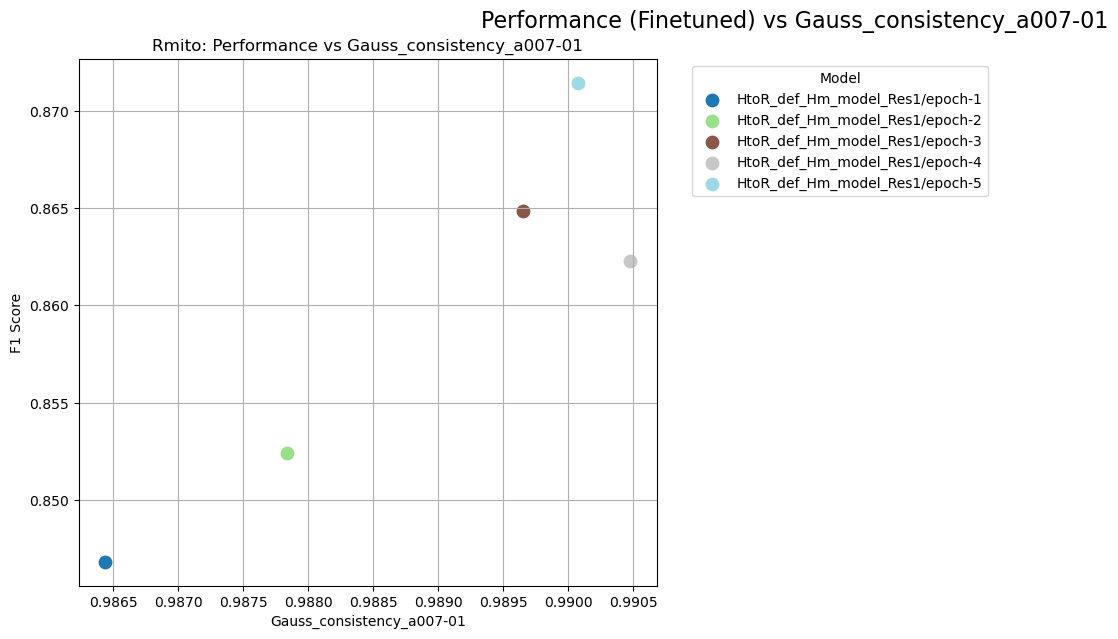

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.6     0.23    0.7        0.23  0.91     0.03
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/HtoR_def_Hm_model_Res1/EI_consis/CMB/transfer_gauss_a01-012_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a01-012
Number of targets: 1
  Target 1: Rmito


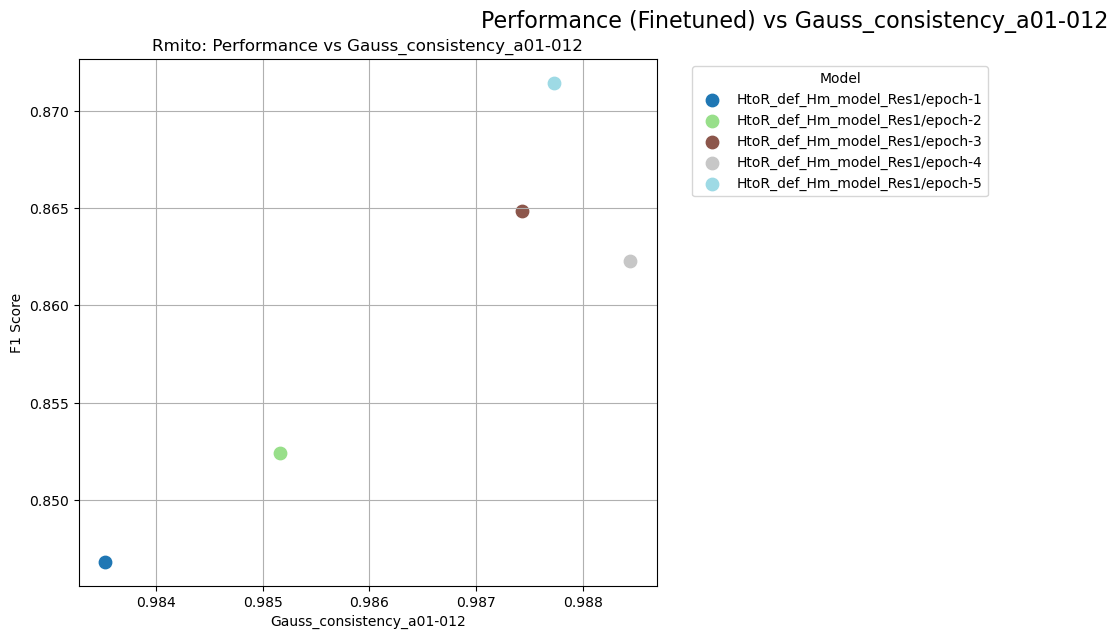

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.6     0.21    0.7        0.21  0.89     0.04
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/HtoR_def_Hm_model_Res1/EI_consis/CMB/transfer_gauss_a012-015_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a012-015
Number of targets: 1
  Target 1: Rmito


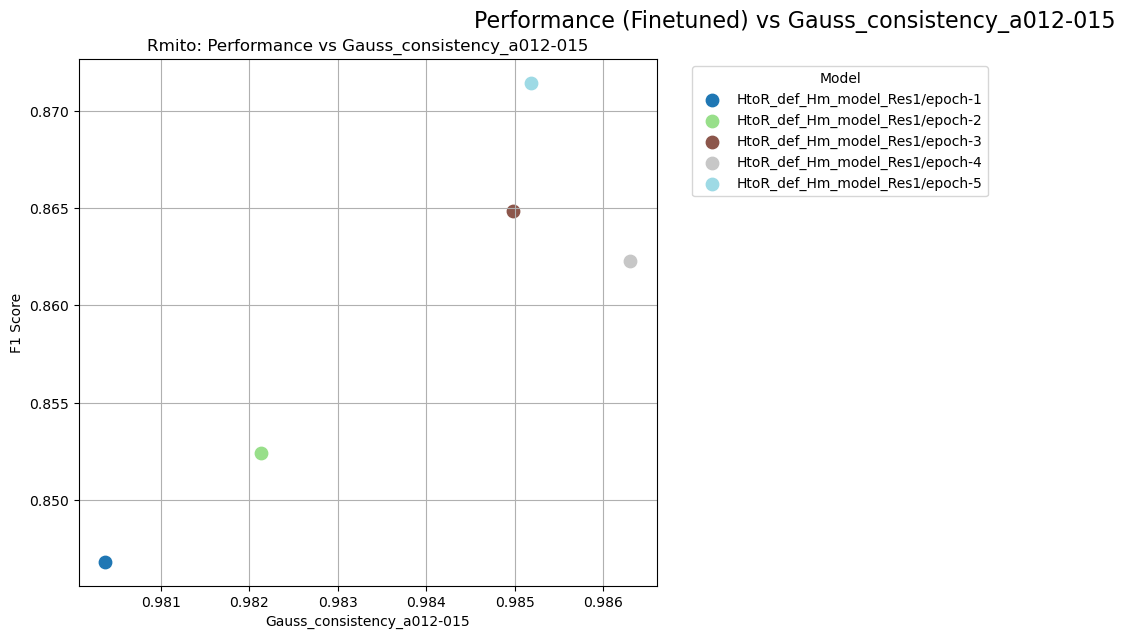

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.6     0.27    0.7        0.22  0.88     0.05
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/HtoR_def_Hm_model_Res1/EI_consis/CMB/transfer_gauss_a015-02_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a015-02
Number of targets: 1
  Target 1: Rmito


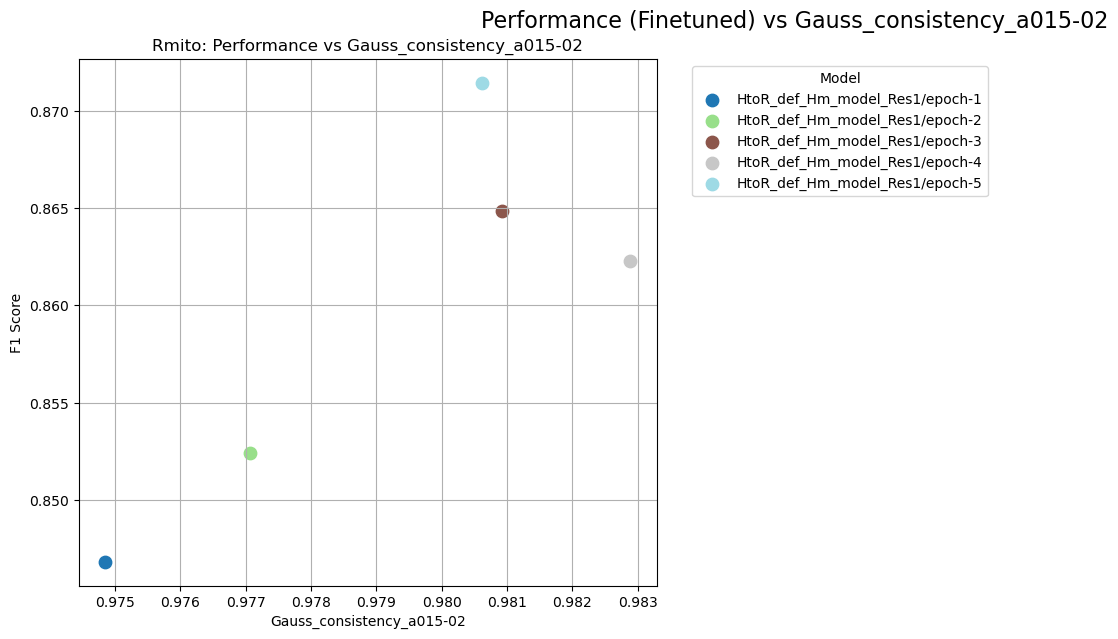

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Rmito    0.4     0.47    0.6        0.35  0.83     0.08


In [6]:
base_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/HtoR_def_Hm_model_Res1/EI_consis/CMB"
selected_augmentations = ["a001-003", "a003-005", "a005-007", "a007-01", "a01-012", "a012-015", "a015-02"]

for aug in selected_augmentations:
    file_name = f"transfer_gauss_{aug}_CMB_05f_05b_EI_scores.json"
    consistency_path = Path(base_path) / file_name
    results = load_transfer_metric_results(consistency_path)
    consistency_scores = results["transfer_scores"]
    targets = list(consistency_scores.keys())
    consistency_scores = match_model_names(
        performance_scores=HtoR_Res_performance_scores,
        transfer_scores=consistency_scores,
    )
    plot_performance_vs_transfer_metric_multi_target(
        performance_scores=HtoR_Res_performance_scores,
        transfer_scores=consistency_scores,
        transfer_metric=f"Gauss_consistency_{aug}",
        finetuned=True,
    )
    KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
        targets=targets,
        transfer_metric_per_target=consistency_scores,
        performance_per_target=HtoR_Res_performance_scores,
        )
    correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
    print(correlation_df)
        
        

# VtoH_def_V_model_NA2

Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_NA2/EI_consis/CMB/transfer_gauss_a001-003_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a001-003
Number of targets: 1
  Target 1: Hmito


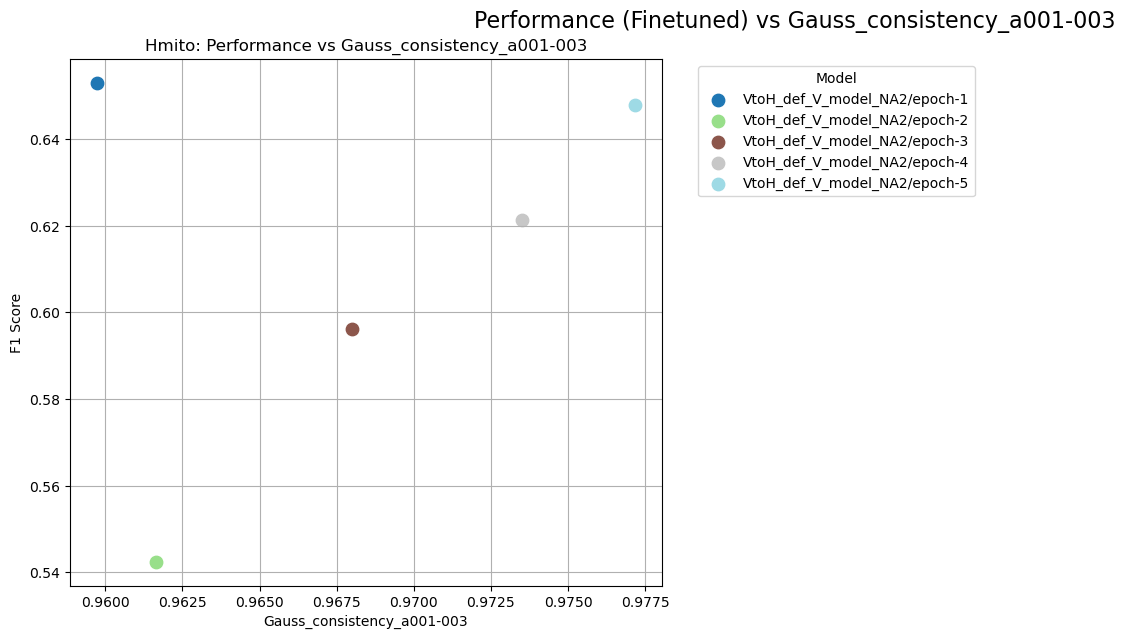

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.2     0.81    0.0         1.0  0.36     0.55
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_NA2/EI_consis/CMB/transfer_gauss_a003-005_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a003-005
Number of targets: 1
  Target 1: Hmito


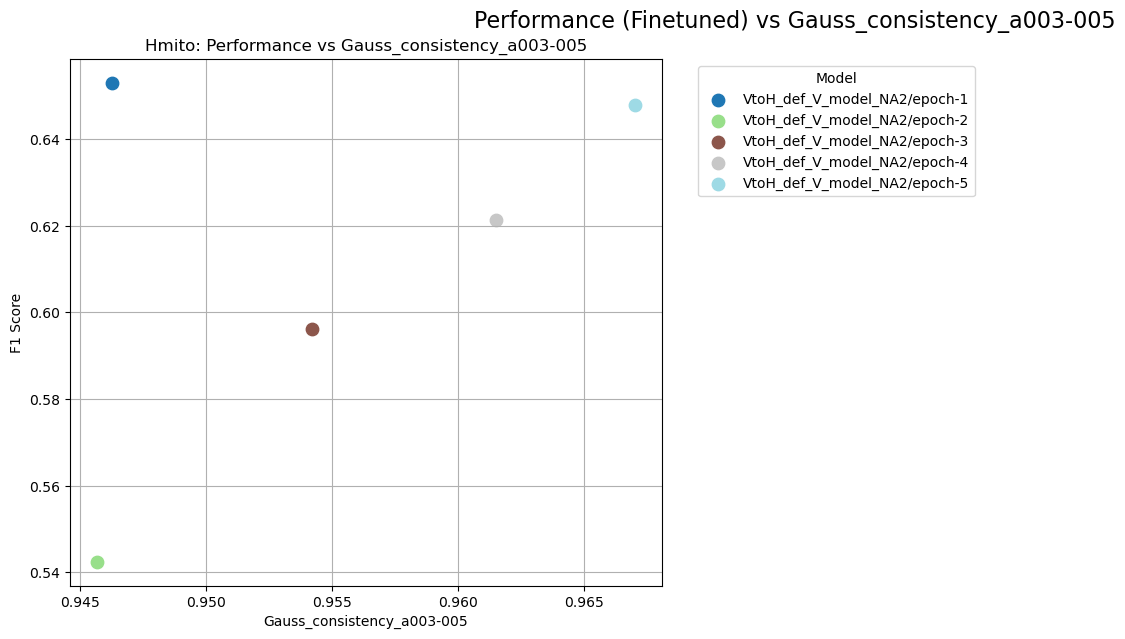

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.4     0.54    0.4        0.54  0.47     0.42
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_NA2/EI_consis/CMB/transfer_gauss_a005-007_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a005-007
Number of targets: 1
  Target 1: Hmito


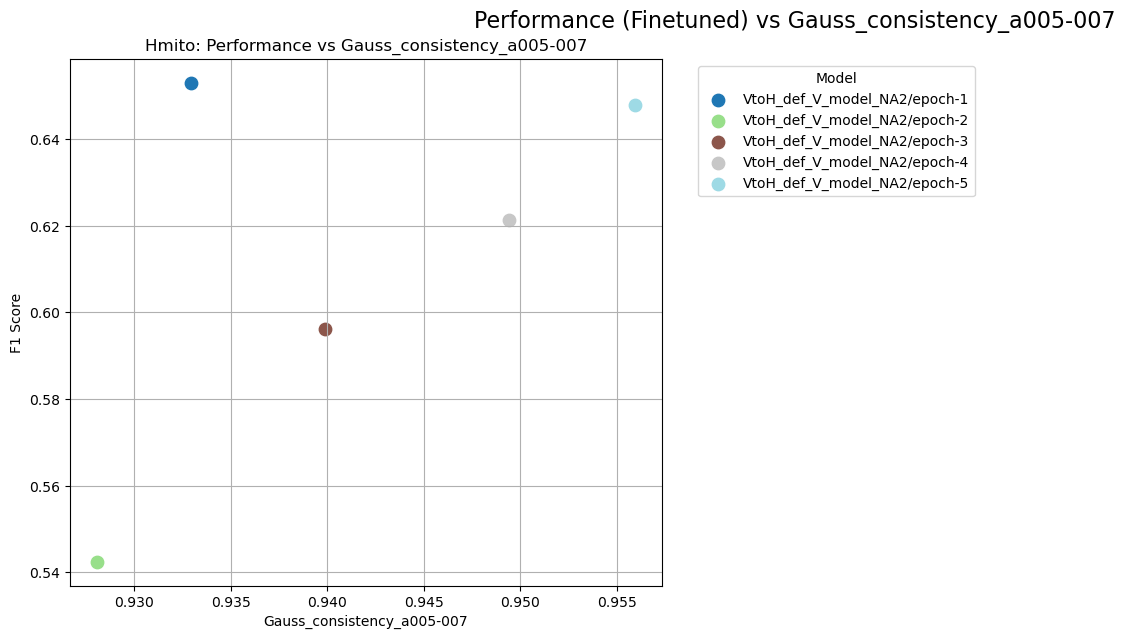

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.4     0.48    0.4        0.52  0.58     0.31
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_NA2/EI_consis/CMB/transfer_gauss_a007-01_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a007-01
Number of targets: 1
  Target 1: Hmito


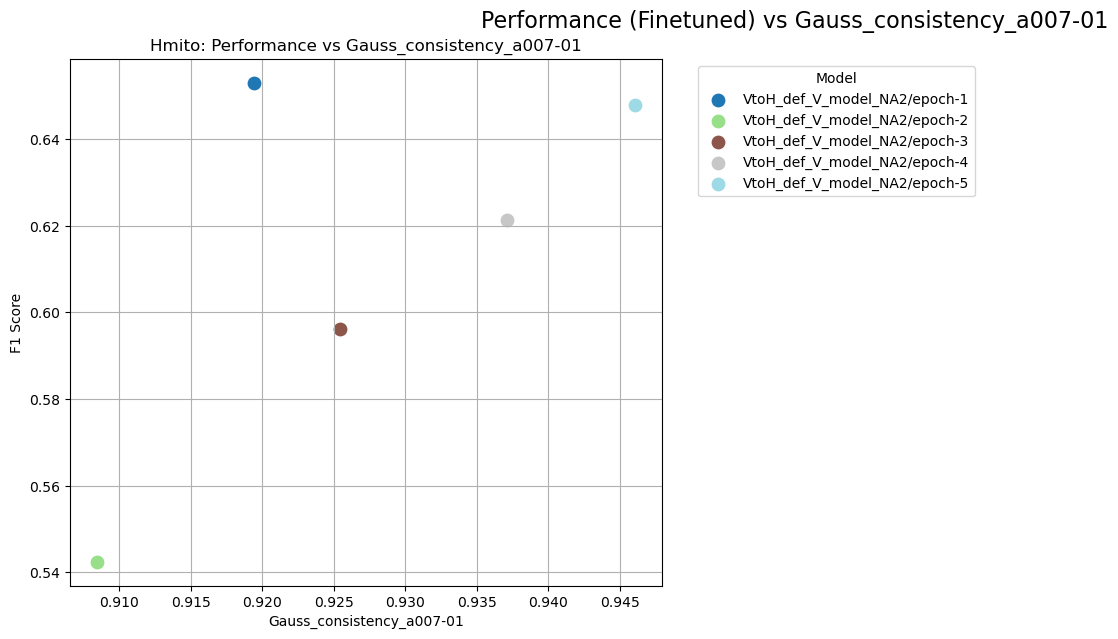

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.4     0.49    0.4        0.55  0.67     0.22
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_NA2/EI_consis/CMB/transfer_gauss_a01-012_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a01-012
Number of targets: 1
  Target 1: Hmito


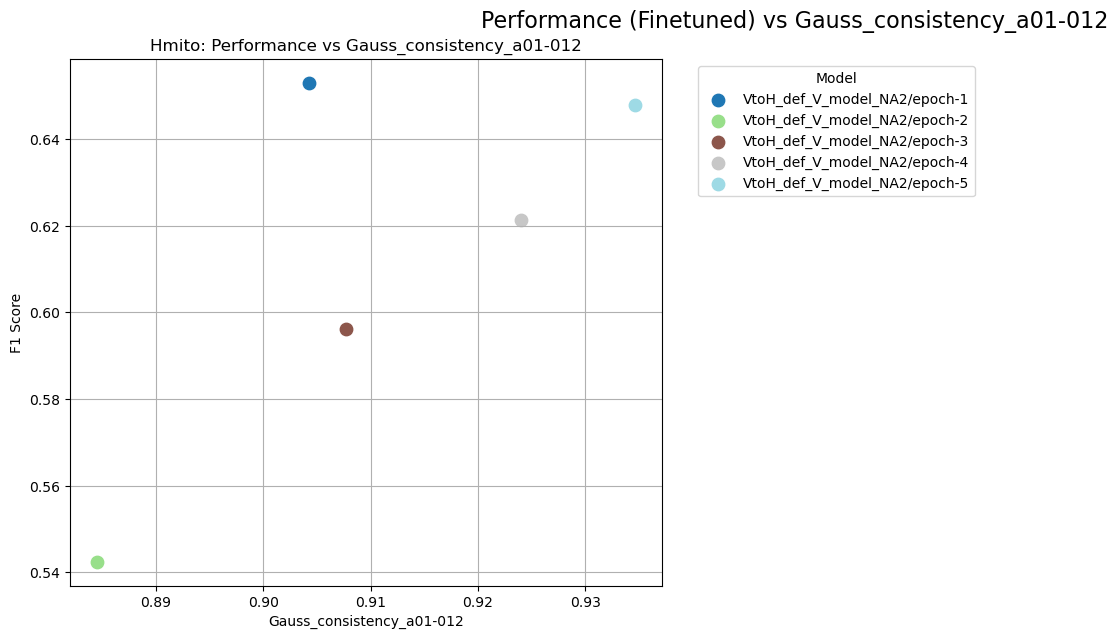

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.4     0.42    0.4        0.45  0.74     0.15
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_NA2/EI_consis/CMB/transfer_gauss_a012-015_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a012-015
Number of targets: 1
  Target 1: Hmito


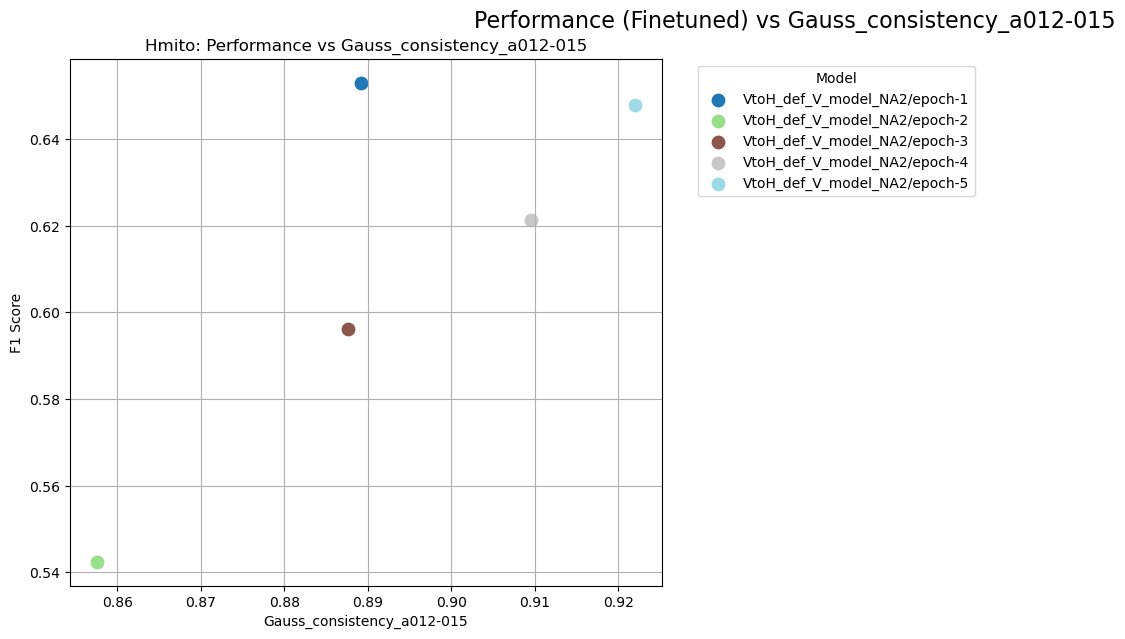

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.6     0.21    0.7        0.19  0.81      0.1
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_NA2/EI_consis/CMB/transfer_gauss_a015-02_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a015-02
Number of targets: 1
  Target 1: Hmito


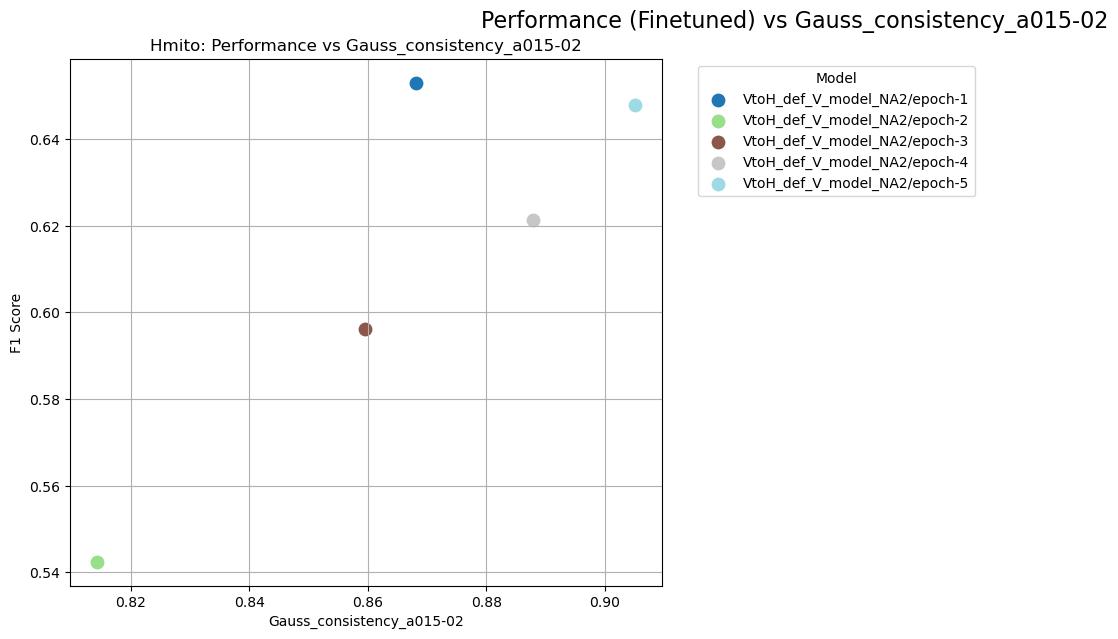

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.6     0.24    0.7        0.25  0.87     0.06


In [8]:
base_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_NA2/EI_consis/CMB"
selected_augmentations = ["a001-003", "a003-005", "a005-007", "a007-01", "a01-012", "a012-015", "a015-02"]

for aug in selected_augmentations:
    file_name = f"transfer_gauss_{aug}_CMB_05f_05b_EI_scores.json"
    consistency_path = Path(base_path) / file_name
    results = load_transfer_metric_results(consistency_path)
    consistency_scores = results["transfer_scores"]
    targets = list(consistency_scores.keys())
    consistency_scores = match_model_names(
        performance_scores=VtoH_NA_performance_scores,
        transfer_scores=consistency_scores,
    )
    plot_performance_vs_transfer_metric_multi_target(
        performance_scores=VtoH_NA_performance_scores,
        transfer_scores=consistency_scores,
        transfer_metric=f"Gauss_consistency_{aug}",
        finetuned=True,
    )
    KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
        targets=targets,
        transfer_metric_per_target=consistency_scores,
        performance_per_target=VtoH_NA_performance_scores,
        )
    correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
    print(correlation_df)
        
        

# VtoH_def_V_model_Res1

Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_Res1/EI_consis/CMB/transfer_gauss_a001-003_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a001-003
Number of targets: 1
  Target 1: Hmito


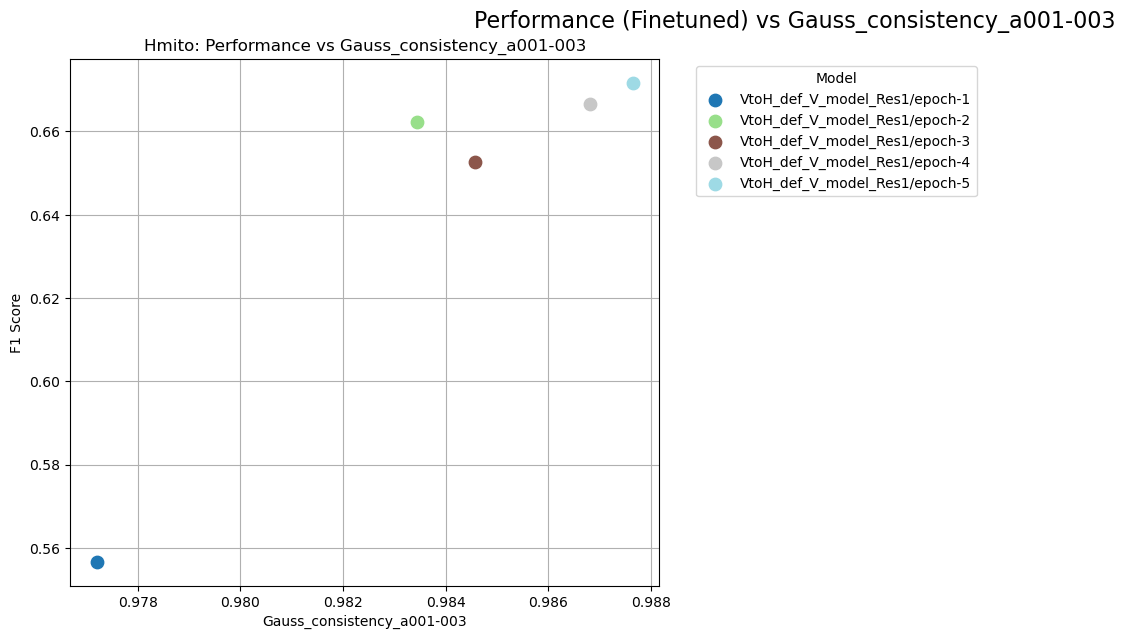

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8     0.09    0.9         0.1  0.95     0.01
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_Res1/EI_consis/CMB/transfer_gauss_a003-005_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a003-005
Number of targets: 1
  Target 1: Hmito


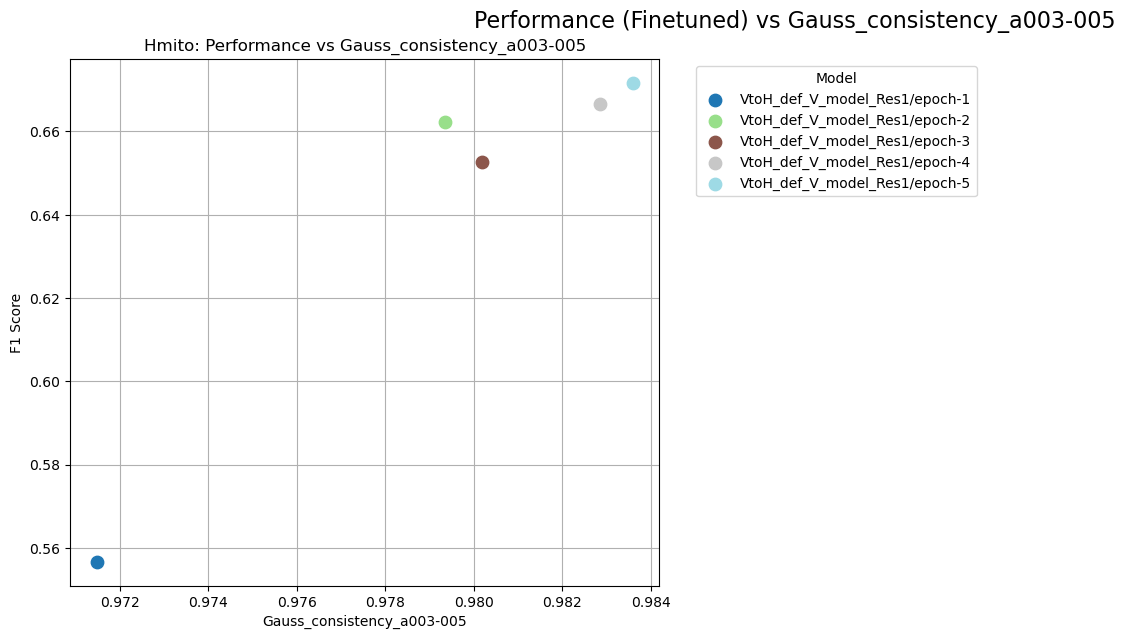

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8      0.1    0.9        0.07  0.96     0.01
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_Res1/EI_consis/CMB/transfer_gauss_a005-007_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a005-007
Number of targets: 1
  Target 1: Hmito


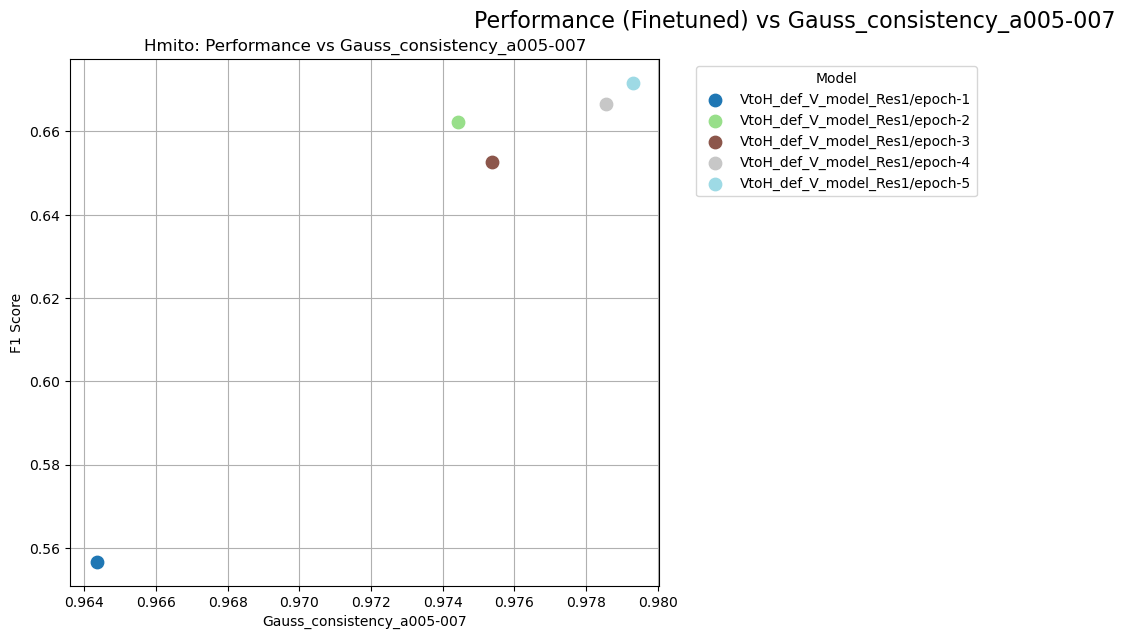

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8     0.09    0.9        0.07  0.97     0.01
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_Res1/EI_consis/CMB/transfer_gauss_a007-01_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a007-01
Number of targets: 1
  Target 1: Hmito


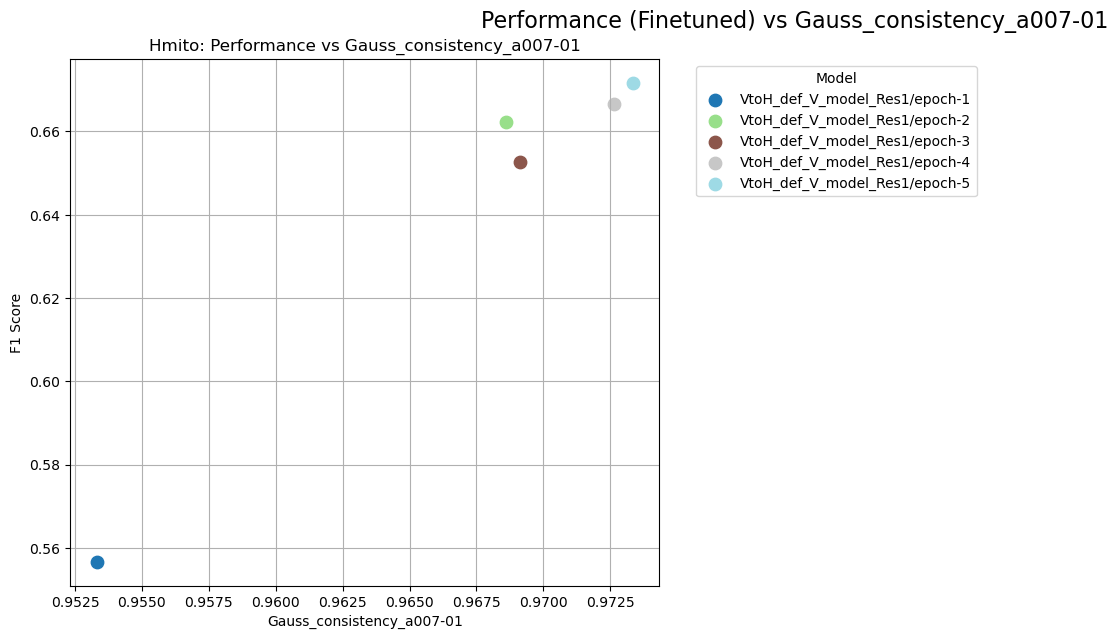

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8     0.08    0.9        0.07  0.99      0.0
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_Res1/EI_consis/CMB/transfer_gauss_a01-012_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a01-012
Number of targets: 1
  Target 1: Hmito


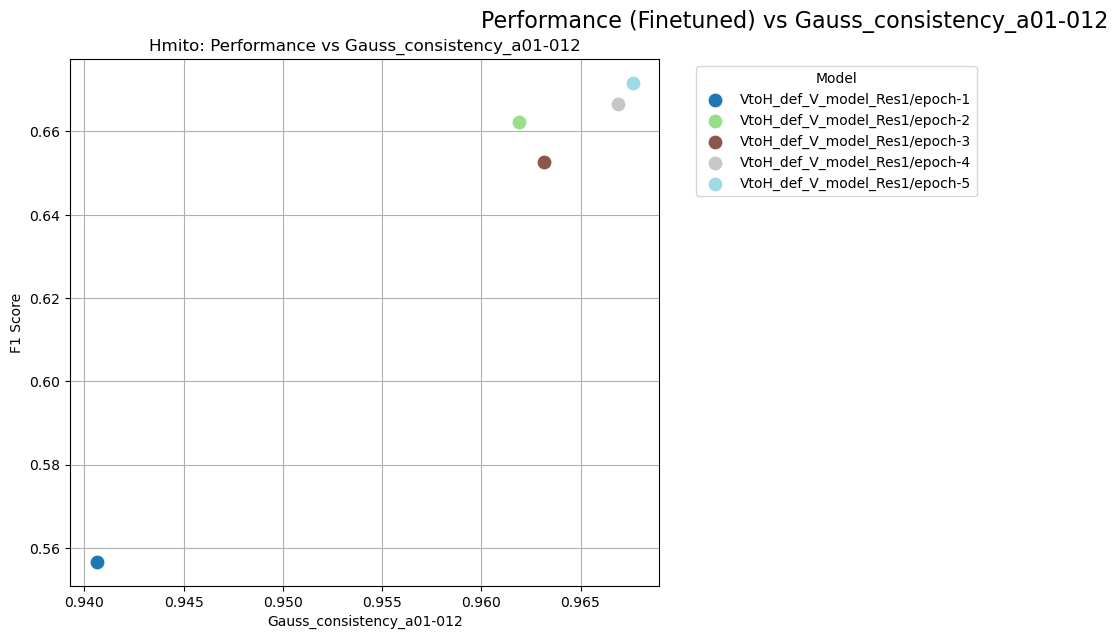

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8     0.07    0.9        0.08  0.99      0.0
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_Res1/EI_consis/CMB/transfer_gauss_a012-015_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a012-015
Number of targets: 1
  Target 1: Hmito


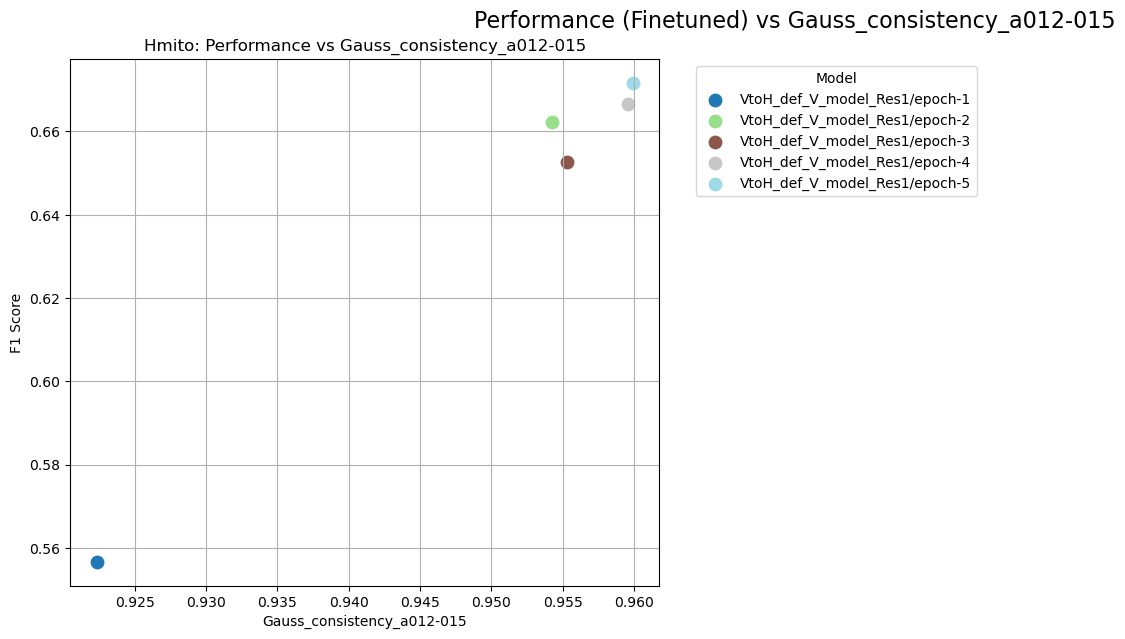

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8     0.07    0.9         0.1  0.99      0.0
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_Res1/EI_consis/CMB/transfer_gauss_a015-02_CMB_05f_05b_EI_scores.json
Processing: Gauss_consistency_a015-02
Number of targets: 1
  Target 1: Hmito


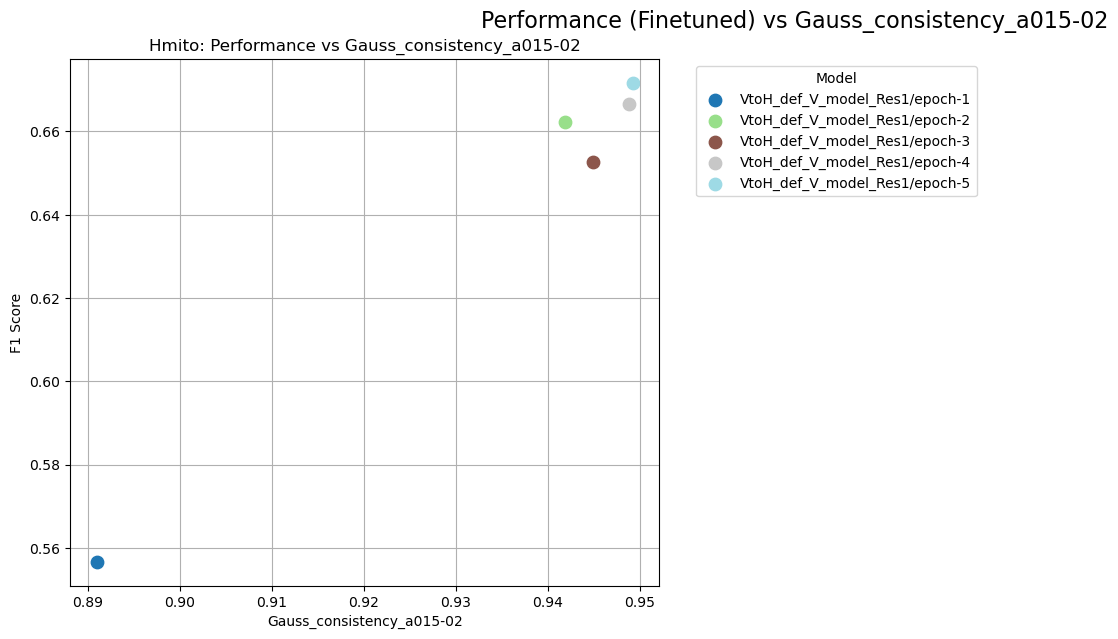

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hmito    0.8     0.12    0.9        0.08  0.99      0.0


In [9]:
base_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/stepwise_finetuned/VtoH_def_V_model_Res1/EI_consis/CMB"
selected_augmentations = ["a001-003", "a003-005", "a005-007", "a007-01", "a01-012", "a012-015", "a015-02"]

for aug in selected_augmentations:
    file_name = f"transfer_gauss_{aug}_CMB_05f_05b_EI_scores.json"
    consistency_path = Path(base_path) / file_name
    results = load_transfer_metric_results(consistency_path)
    consistency_scores = results["transfer_scores"]
    targets = list(consistency_scores.keys())
    consistency_scores = match_model_names(
        performance_scores=VtoH_Res_performance_scores,
        transfer_scores=consistency_scores,
    )
    plot_performance_vs_transfer_metric_multi_target(
        performance_scores=VtoH_Res_performance_scores,
        transfer_scores=consistency_scores,
        transfer_metric=f"Gauss_consistency_{aug}",
        finetuned=True,
    )
    KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
        targets=targets,
        transfer_metric_per_target=consistency_scores,
        performance_per_target=VtoH_Res_performance_scores,
        )
    correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
    print(correlation_df)
        
        